SETUP

In [1]:
import os, ast, json, random, numpy as np, pandas as pd, wfdb, tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, precision_recall_curve, f1_score
tf.random.set_seed(42); np.random.seed(42); random.seed(42)


In [2]:
PTBXL_ROOT = "/Users/sahandissanayake/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"
ptbxl_csv = os.path.join(PTBXL_ROOT, "ptbxl_database.csv")
scp_csv   = os.path.join(PTBXL_ROOT, "scp_statements.csv")
assert os.path.exists(ptbxl_csv) and os.path.exists(scp_csv), "Check PTB-XL paths."

In [3]:
df = pd.read_csv(ptbxl_csv)
scp_df = pd.read_csv(scp_csv)

# Normalize columns; ensure we have ['scp','diagnostic_class']
scp_df = scp_df.copy()
scp_df.columns = scp_df.columns.str.strip()
if "scp" not in scp_df.columns:
    if "Unnamed: 0" in scp_df.columns:
        scp_df = scp_df.rename(columns={"Unnamed: 0": "scp"})
    elif scp_df.index.name:
        scp_df = scp_df.reset_index().rename(columns={scp_df.columns[0]: "scp"})
    else:
        # fallback: use first non-diagnostic_class column as scp
        candidates = [c for c in scp_df.columns if c != "diagnostic_class"]
        scp_df = scp_df.rename(columns={candidates[0]: "scp"})

assert "scp" in scp_df.columns, f"Missing 'scp' column: {scp_df.columns.tolist()}"
assert "diagnostic_class" in scp_df.columns, "'diagnostic_class' column missing."

# Build mapping: SCP code -> diagnostic_class (NORM/MI/STTC/HYP/CD)
scp_df["scp"] = scp_df["scp"].astype(str).str.strip()
scp_df["diagnostic_class"] = scp_df["diagnostic_class"].astype(str).str.strip()
scp_to_class = dict(zip(scp_df["scp"], scp_df["diagnostic_class"]))


In [4]:
import ast
from sklearn.preprocessing import LabelEncoder


scp_to_class = {
    "NORM": "NORM",     # Normal ECG
    "MI": "MI",         # Myocardial Infarction
    "STTC": "STTC",     # ST/T changes
    "HYP": "HYP",       # Hypertrophy
    "CD": "CD",         # Conduction Disturbance
    "SBRAD": "CD",
    "LAFB": "CD",
    "LBBB": "CD",
    "RBBB": "CD",
    "IRBBB": "CD",
    "CRBBB": "CD",
    "AVB": "CD",
    "PVC": "CD",
    "PAC": "CD",
    "LAE": "HYP",
    "LVH": "HYP",
    "RAE": "HYP",
    "RVH": "HYP",
    "ISC": "MI",
    "IMI": "MI",
    "ILMI": "MI",
    "ILAF": "MI",
    "ASMI": "MI",
    "INMI": "MI",
    "STACH": "STTC",
    "NST": "STTC",
    "TINV": "STTC",
    "STDEP": "STTC",
    "STEMI": "MI",
    "STD": "STTC",
    "TNEG": "STTC",
    "STEL": "STTC",
    "SVT": "CD",
    "AFIB": "CD",
    "AFL": "CD",

}
def parse_scp_codes(s):
    if isinstance(s, dict):
        return s
    if isinstance(s, str):
        try:
            return ast.literal_eval(s)
        except Exception:
            return {}
    return {}

def majority_diag_class(scp_codes_dict):
    # choose diagnostic_class with the largest weight among present SCPs
    bucket = {}
    for scp, w in scp_codes_dict.items():
        dc = scp_to_class.get(str(scp))
        if dc is not None:
            bucket[dc] = bucket.get(dc, 0.0) + float(w)
    return max(bucket, key=bucket.get) if bucket else None

# Defensive: check for required columns
required_cols = {"scp_codes", "strat_fold", "filename_lr"}
assert required_cols.issubset(df.columns), f"Missing columns: {required_cols - set(df.columns)}"

df = df.copy()
df["scp_codes_dict"] = df["scp_codes"].apply(parse_scp_codes)
df["y_class"] = df["scp_codes_dict"].apply(majority_diag_class)
df = df.dropna(subset=["y_class"]).reset_index(drop=True)

# Encode to ints 0..K-1 on full df
le = LabelEncoder()
le.fit(df["y_class"])  # fit on all data so folds map consistently
df["y_int"] = le.transform(df["y_class"]).astype("int32")
n_classes = len(le.classes_)
print("Classes -> ids:", dict(zip(le.classes_, le.transform(le.classes_))))

# Create a path column (low-rate ECG, no extension)
df["record_path"] = df["filename_lr"]

# Patient-wise split using provided folds
train_idx = df["strat_fold"].isin(range(1, 9))
val_idx   = df["strat_fold"].eq(9)
test_idx  = df["strat_fold"].eq(10)

df_train = df[train_idx].copy()
df_val   = df[val_idx].copy()
df_test  = df[test_idx].copy()

for name, d in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(name, len(d), "unique y_int:", sorted(d["y_int"].unique()))

Classes -> ids: {'CD': np.int64(0), 'HYP': np.int64(1), 'MI': np.int64(2), 'NORM': np.int64(3), 'STTC': np.int64(4)}
train 14936 unique y_int: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
val 1853 unique y_int: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
test 1870 unique y_int: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


In [15]:
from tensorflow.keras import layers, Model

INPUT_LEN, N_LEADS, BATCH = 1000, 12, 64
def se_block(x, r=16):
    c = x.shape[-1]
    s = layers.GlobalAveragePooling1D()(x)
    s = layers.Dense(max(1, c//r), activation="relu")(s)
    s = layers.Dense(c, activation="sigmoid")(s)
    return layers.Multiply()([x, layers.Reshape((1, c))(s)])

def res_block(x, filters, kernel=7, stride=1):
    shortcut = x
    x = layers.Conv1D(filters, kernel, strides=stride, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv1D(filters, kernel, padding="same")(x)
    x = layers.BatchNormalization()(x); x = se_block(x)
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut]); x = layers.Activation("relu")(x)
    return x

class AttentionLayer(layers.Layer):
    """Simple additive attention over time: (B,T,F) -> (B,F)"""
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.W = layers.Dense(units, activation="tanh")
        self.v = layers.Dense(1)

    def call(self, inputs, mask=None):
        # inputs: (B, T, F)
        score = self.v(self.W(inputs))                 # (B, T, 1)
        if mask is not None:
            mask = tf.cast(mask[:, :, None], score.dtype)
            score = score - 1e9 * (1.0 - mask)         # mask padded steps
        weights = tf.nn.softmax(score, axis=1)         # (B, T, 1)
        context = tf.reduce_sum(inputs * weights, axis=1)  # (B, F)
        return context

# Replace build_model_multiclass

def build_model_multiclass(input_len=1000, n_leads=12, n_classes=5):
    """Improved architecture with more capacity"""
    inputs = layers.Input(shape=(input_len, n_leads))

    # Stem
    x = layers.Conv1D(32, 7, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Residual groups (use existing res_block)
    # Group 1: 32 filters
    x = res_block(x, 32, kernel=7, stride=1)
    x = res_block(x, 32, kernel=7, stride=1)

    # Group 2: 64 filters, downsample via stride=2
    x = res_block(x, 64, kernel=7, stride=2)
    x = res_block(x, 64, kernel=7, stride=1)

    # Group 3: 128 filters, downsample
    x = res_block(x, 128, kernel=7, stride=2)
    x = res_block(x, 128, kernel=7, stride=1)

    # (Optional) one more group:
    x = res_block(x, 160, kernel=5, stride=2)
    x = res_block(x, 160, kernel=5, stride=1)

    # Sequence encoder
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

    # Attention pooling
    x = AttentionLayer(units=64)(x)

    # Classification head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    
    return Model(inputs, outputs)

model = build_model_multiclass(INPUT_LEN, N_LEADS, n_classes)
top2 = tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top2')
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(name="top2", k=2),
    ],
)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 1000, 32)  │      2,720 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1000, 32)  │        128 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1000, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 1000, 32)  │      7,200 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 32)  │        128 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1000, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 1000, 32)  │      7,200 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 32)  │        128 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 2)         │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │         96 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 32)     │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1000, 32)  │          0 │ batch_normalizat… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1000, 32)  │          0 │ multiply[0][0],   │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1000, 32)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 1000, 32)  │      7,200 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1000, 32)  │        128 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 1000, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 1,213,110 (4.63 MB)

 Trainable params: 1,209,270 (4.61 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [16]:
AUTO = tf.data.AUTOTUNE


def read_wfdb_record(rel_wo_ext, root=PTBXL_ROOT):
    # rel_wo_ext like 'records100/00000/00001/00001_lr'
    p = os.path.join(root, rel_wo_ext)
    sig, _ = wfdb.rdsamp(p)                # (T, 12)
    return sig.astype(np.float32)

def _py_load_mc(path_bytes, y_int):
    path = path_bytes.numpy().decode("utf-8")
    sig = read_wfdb_record(path)           # expect (1000, 12) for LR
    # pad/trim if needed
    if sig.shape != (INPUT_LEN, N_LEADS):
        out = np.zeros((INPUT_LEN, N_LEADS), np.float32)
        T = min(INPUT_LEN, sig.shape[0]); C = min(N_LEADS, sig.shape[1])
        out[:T, :C] = sig[:T, :C]
        sig = out
    # per-lead z-score
    m = sig.mean(0, keepdims=True); s = sig.std(0, keepdims=True) + 1e-6
    sig = (sig - m) / s
    return sig.astype(np.float32), np.int32(y_int)

def make_ds_mc_sparse(df_part, shuffle=False):
    paths = df_part["record_path"].tolist()
    ys    = df_part["y_int"].astype("int32").tolist()
    ds = tf.data.Dataset.from_tensor_slices((paths, ys))
    ds = ds.map(lambda p,y: tf.py_function(_py_load_mc, [p,y], [tf.float32, tf.int32]),
                num_parallel_calls=AUTO)
    ds = ds.map(lambda x,y: (tf.ensure_shape(x, [INPUT_LEN, N_LEADS]),
                             tf.ensure_shape(y, [])),
                num_parallel_calls=AUTO)
    if shuffle:
        ds = ds.shuffle(4096, reshuffle_each_iteration=True)
    return ds.batch(BATCH).prefetch(AUTO)

train_ds = make_ds_mc_sparse(df_train, shuffle=True)
val_ds   = make_ds_mc_sparse(df_val)
test_ds  = make_ds_mc_sparse(df_test)

# sanity peek
for xb, yb in train_ds.take(1):
    print("xb:", xb.shape, xb.dtype)   # (B,1000,12) float32
    print("yb:", yb.shape, yb.dtype)   # (B,) int32 with values in [0, n_classes-1]


def make_ds_mc_sparse(df_part, shuffle=False):
    paths = df_part["record_path"].tolist()
    ys    = df_part["y_int"].astype("int32").tolist()
    ds = tf.data.Dataset.from_tensor_slices((paths, ys))
    ds = ds.map(lambda p,y: tf.py_function(_py_load_mc, [p,y], [tf.float32, tf.int32]),
                num_parallel_calls=AUTO)
    ds = ds.map(lambda x,y: (tf.ensure_shape(x, [INPUT_LEN, N_LEADS]),
                             tf.ensure_shape(y, [])),
                num_parallel_calls=AUTO)
    if shuffle:
        ds = ds.shuffle(4096, reshuffle_each_iteration=True)
    return ds.batch(BATCH).prefetch(AUTO)

train_ds = make_ds_mc_sparse(df_train, shuffle=True)
val_ds   = make_ds_mc_sparse(df_val)
test_ds  = make_ds_mc_sparse(df_test)

# sanity peek
for xb, yb in train_ds.take(1):
    print("xb:", xb.shape, xb.dtype)   # (B,1000,12) float32
    print("yb:", yb.shape, yb.dtype)   # (B,) int32 with values in [0, n_classes-1]


xb: (64, 1000, 12) <dtype: 'float32'>
yb: (64,) <dtype: 'int32'>


2025-11-12 16:46:35.082035: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


xb: (64, 1000, 12) <dtype: 'float32'>
yb: (64,) <dtype: 'int32'>


In [17]:
# ===== CRITICAL: Ensure NO mixed precision =====
import tensorflow as tf
from tensorflow.keras import mixed_precision

# Force float32 policy
mixed_precision.set_global_policy('float32')
print(f"✓ Current policy: {mixed_precision.global_policy().name}")

# Compute class weights
classes = np.arange(n_classes)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=df_train["y_int"].values)
class_weight = {int(k): float(v) for k, v in zip(classes, cw)}
print("class_weight:", class_weight)

# Create checkpoint directory
ckpt_path = "/Users/sahandissanayake/Documents/PythonLib 3.11/models/best_ptbxl_cvd_mc.keras"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

# Define callbacks
cbs = [
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
]

# Optimize data pipeline (recreate without caching to avoid type issues)
AUTOTUNE = tf.data.AUTOTUNE

# Recreate datasets fresh
train_ds = make_ds_mc_sparse(df_train, shuffle=True)
val_ds   = make_ds_mc_sparse(df_val)

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

# Verify data types
for xb, yb in train_ds.take(1):
    print(f"✓ Train batch types: x={xb.dtype}, y={yb.dtype}")
    assert xb.dtype == tf.float32, f"Expected float32, got {xb.dtype}"

# Re-compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2')
    ]
)

print("✓ Model compiled successfully")

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=cbs,
)

✓ Current policy: float32
class_weight: {0: 1.0219637358877864, 1: 2.3102861562258314, 2: 0.9349608763693271, 3: 0.4044955991875423, 4: 21.337142857142858}
✓ Train batch types: x=<dtype: 'float32'>, y=<dtype: 'int32'>
✓ Model compiled successfully
Epoch 1/20


2025-11-12 16:46:43.551325: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.4666 - loss: 1.2555 - top2: 0.6819
Epoch 1: val_accuracy improved from None to 0.57420, saving model to /Users/sahandissanayake/Documents/PythonLib 3.11/models/best_ptbxl_cvd_mc.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 106s 408ms/step - accuracy: 0.5761 - loss: 1.0804 - top2: 0.7862 - val_accuracy: 0.5742 - val_loss: 1.0305 - val_top2: 0.8176 - learning_rate: 3.0000e-04
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.6626 - loss: 0.8906 - top2: 0.8611
Epoch 2: val_accuracy improved from 0.57420 to 0.68861, saving model to /Users/sahandissanayake/Documents/PythonLib 3.11/models/best_ptbxl_cvd_mc.keras
234/234 ━━━━━━━━━━━━━━━━━━━━ 113s 485ms/step - accuracy: 0.6842 - loss: 0.8396 - top2: 0.8787 - val_accuracy: 0.6886 - val_loss: 0.7906 - val_top2: 0.9050 - learning_rate: 3.0000e-04
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.6978 - loss: 0.7680 - top2: 0.8916
Epoch 3: val_accuracy improved from

In [18]:
from tensorflow import keras
model = keras.models.load_model("/Users/sahandissanayake/Documents/PythonLib 3.11/models/best_ptbxl_cvd_mc.keras")

TypeError: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}, 'compile_config': {'optimizer': {'module': 'keras.optimizers', 'class_name': 'Adam', 'config': {'name': 'adam', 'learning_rate': 3.7500001781154424e-05, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}, 'registered_name': None}, 'loss': 'sparse_categorical_crossentropy', 'loss_weights': None, 'metrics': ['accuracy', {'

In [19]:
# Keras metrics
print(model.evaluate(test_ds, return_dict=True))

# Sklearn report
from sklearn.metrics import confusion_matrix # Import confusion_matrix
y_true = df_test["y_int"].values
y_prob = np.concatenate([model.predict(test_ds)], axis=0)      # (N, n_classes)
y_pred = y_prob.argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=list(le.classes_), digits=4))
print(confusion_matrix(y_true, y_pred))

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.7385 - loss: 0.9215 - top2: 0.9219
{'accuracy': 0.7385026812553406, 'loss': 0.9215458631515503, 'top2': 0.9219251275062561}
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step
              precision    recall  f1-score   support

          CD     0.6273    0.6602    0.6433       362
         HYP     0.4676    0.4114    0.4377       158
          MI     0.6934    0.6291    0.6597       399
        NORM     0.8491    0.8774    0.8630       930
        STTC     0.3704    0.4762    0.4167        21

    accuracy                         0.7385      1870
   macro avg     0.6016    0.6109    0.6041      1870
weighted avg     0.7353    0.7385    0.7362      1870

[[239  25  44  51   3]
 [ 28  65  23  39   3]
 [ 67  23 251  54   4]
 [ 43  24  40 816   7]
 [  4   2   4   1  10]]


In [20]:
def predict_diagnosis_from_wfdb(rel_wo_ext, thresholding=False):
    sig = read_wfdb_record(rel_wo_ext)   # (1000,12)
    m, s = sig.mean(0, keepdims=True), sig.std(0, keepdims=True) + 1e-6
    sig = (sig - m) / s
    probs = model.predict(sig[None, ...])[0]
    cls_id = int(np.argmax(probs))
    return {
        "pred_class": le.classes_[cls_id],
        "probs": {cls: float(p) for cls, p in zip(le.classes_, probs)}
    }

# Example using the first record in the test set:
print("Prediction for the first record in the test set:")
display(predict_diagnosis_from_wfdb(df_test.iloc[0]["record_path"]))

# Example using the second record in the test set:
print("\nPrediction for the second record in the test set:")
display(predict_diagnosis_from_wfdb(df_test.iloc[1]["record_path"]))

Prediction for the first record in the test set:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step


{'pred_class': 'NORM',
 'probs': {'CD': 0.00046505266800522804,
  'HYP': 0.00022562278900295496,
  'MI': 0.0006079035811126232,
  'NORM': 0.9986947178840637,
  'STTC': 6.799365564802429e-06}}


Prediction for the second record in the test set:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


{'pred_class': 'NORM',
 'probs': {'CD': 0.008614080026745796,
  'HYP': 0.00030201562913134694,
  'MI': 0.009267069399356842,
  'NORM': 0.981745719909668,
  'STTC': 7.114301843103021e-05}}

In [21]:
# Example
print("Prediction for the first record in the test set:")
display(predict_diagnosis_from_wfdb(df_test.iloc[27]["record_path"]))

# Example
print("\nPrediction for the second record in the test set:")
display(predict_diagnosis_from_wfdb(df_test.iloc[34]["record_path"]))

Prediction for the first record in the test set:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


{'pred_class': 'MI',
 'probs': {'CD': 0.0012254550820216537,
  'HYP': 0.0009880352299660444,
  'MI': 0.6584348678588867,
  'NORM': 0.3391212224960327,
  'STTC': 0.0002305487432749942}}


Prediction for the second record in the test set:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


{'pred_class': 'HYP',
 'probs': {'CD': 0.00035138215753249824,
  'HYP': 0.7848423719406128,
  'MI': 0.21353095769882202,
  'NORM': 0.001204941887408495,
  'STTC': 7.02304023434408e-05}}

In [22]:
import numpy as np
import wfdb
import pandas as pd
import scipy.io
import os
import json

def load_ecg_file(file_path):
    ext = os.path.splitext(file_path)[-1].lower()
    if ext in ['.dat', '.hea', '']:  # WFDB (assumes .dat/.hea, no extension)
        sig, _ = wfdb.rdsamp(file_path)
        return sig
    elif ext == '.csv':
        df = pd.read_csv(file_path)
        sig = df.select_dtypes(include=[np.number]).values
        return sig
    elif ext == '.npy':
        sig = np.load(file_path)
        return sig
    elif ext == '.mat':
        mat = scipy.io.loadmat(file_path)
        for key in ['ecg', 'signal', 'val', 'data']:
            if key in mat:
                return np.array(mat[key])
        raise ValueError("MAT file: No ECG signal found in keys.")
    elif ext == '.json':
        with open(file_path, 'r') as f:
            jdata = json.load(f)
        # Try common keys for ECG data
        for key in ['ecg', 'signal', 'val', 'data']:
            if key in jdata:
                sig = np.array(jdata[key])
                if sig.ndim == 1:  # Single lead or flat, make shape (T, 1)
                    sig = sig.reshape(-1, 1)
                return sig
        # If top-level is a list (not dict), treat as signal array
        if isinstance(jdata, list):
            sig = np.array(jdata)
            if sig.ndim == 1:
                sig = sig.reshape(-1, 1)
            return sig
        raise ValueError("JSON file: No ECG signal found in keys or top-level list.")
    else:
        raise ValueError(f"Unsupported file type: {file_path}")

def preprocess_ecg(sig, input_len=1000, n_leads=12):
    sig = np.asarray(sig, dtype=np.float32)
    out = np.zeros((input_len, n_leads), np.float32)
    T = min(input_len, sig.shape[0])
    C = min(n_leads, sig.shape[1])
    out[:T, :C] = sig[:T, :C]
    m = out.mean(0, keepdims=True)
    s = out.std(0, keepdims=True) + 1e-6
    out = (out - m) / s
    return out

def predict_cvd(file_path, model, label_encoder, input_len=1000, n_leads=12):
    sig = load_ecg_file(file_path)
    sig = preprocess_ecg(sig, input_len=input_len, n_leads=n_leads)
    pred = model.predict(sig[None, ...])[0]
    class_id = int(np.argmax(pred))
    return {
        'pred_class': label_encoder.classes_[class_id],
        'probs': {cls: float(p) for cls, p in zip(label_encoder.classes_, pred)}
    }

# Test with an actual PTB-XL record (already preprocessed by the model)
# This uses the existing predict_diagnosis_from_wfdb function instead
test_record_path = df_test.iloc[0]["record_path"]
print("Testing with PTB-XL record:")
print(predict_diagnosis_from_wfdb(test_record_path))

Testing with PTB-XL record:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
{'pred_class': 'NORM', 'probs': {'CD': 0.00046505266800522804, 'HYP': 0.00022562278900295496, 'MI': 0.0006079035811126232, 'NORM': 0.9986947178840637, 'STTC': 6.799365564802429e-06}}


In [23]:
# Example: Predict
my_file = "/Users/sahandissanayake/Documents/my_ecg_file.mat"  # or .csv, .npy, .json

if os.path.exists(my_file):
    prediction = predict_cvd(my_file, model, le)
    print(prediction)
else:
    print(f"File not found. Please update the path.")
    print("Using PTB-XL test example instead:")
    print(predict_diagnosis_from_wfdb(df_test.iloc[0]["record_path"]))

File not found. Please update the path.
Using PTB-XL test example instead:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
{'pred_class': 'NORM', 'probs': {'CD': 0.00046505266800522804, 'HYP': 0.00022562278900295496, 'MI': 0.0006079035811126232, 'NORM': 0.9986947178840637, 'STTC': 6.799365564802429e-06}}



Train set: 14936 samples
  CD     count= 2923  pct=19.57%
  HYP    count= 1293  pct= 8.66%
  MI     count= 3195  pct=21.39%
  NORM   count= 7385  pct=49.44%
  STTC   count=  140  pct= 0.94%

Val set: 1853 samples
  CD     count=  376  pct=20.29%
  HYP    count=  157  pct= 8.47%
  MI     count=  376  pct=20.29%
  NORM   count=  922  pct=49.76%
  STTC   count=   22  pct= 1.19%

Test set: 1870 samples
  CD     count=  362  pct=19.36%
  HYP    count=  158  pct= 8.45%
  MI     count=  399  pct=21.34%
  NORM   count=  930  pct=49.73%
  STTC   count=   21  pct= 1.12%

Combined summary:


,Train,Val,Test,Total,Total_pct
y_class,,,,,
CD,2923,376,362,3661,19.62
HYP,1293,157,158,1608,8.62
MI,3195,376,399,3970,21.28
NORM,7385,922,930,9237,49.50
STTC,140,22,21,183,0.98


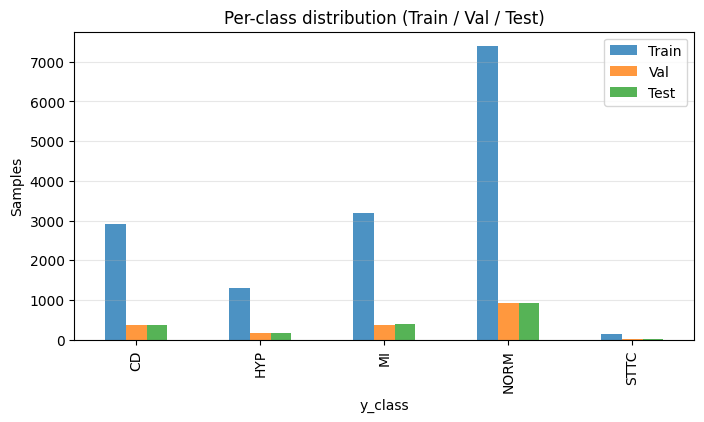

In [24]:
# ...existing code...

import pandas as pd

def summarize(df, name):
    counts = df['y_class'].value_counts().sort_index()
    total = counts.sum()
    pct = (counts / total * 100).round(2)
    print(f"\n{name} set: {total} samples")
    for cls in counts.index:
        print(f"  {cls:5}  count={counts[cls]:5}  pct={pct[cls]:5.2f}%")
    return counts.rename(name)

train_counts = summarize(df_train, "Train")
val_counts   = summarize(df_val, "Val")
test_counts  = summarize(df_test, "Test")

# Combine into one DataFrame
summary_df = pd.concat([train_counts, val_counts, test_counts], axis=1).fillna(0).astype(int)
summary_df['Total'] = summary_df.sum(axis=1)
summary_df['Total_pct'] = (summary_df['Total'] / summary_df['Total'].sum() * 100).round(2)

print("\nCombined summary:")
display(summary_df)

# Optional: stacked bar plot
ax = summary_df[['Train','Val','Test']].plot(kind='bar', figsize=(8,4), stacked=False, alpha=0.8)
ax.set_ylabel("Samples")
ax.set_title("Per-class distribution (Train / Val / Test)")
ax.grid(axis='y', alpha=0.3)
# ...existing code...